In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikitplot as skplt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix, 
    classification_report
)
from copy import deepcopy
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial'

# DeepSP with attention

In [11]:
df_att = pd.read_csv('./DeepSP_att/trainresult.csv', index_col=0)
df_att.head()

,Cytosol,ER,Golgi,Mitochondrion,PM,Plastid,Ribosome,Vacuole,markers,score,pred,FDR,qvalue
Protein_ID,,,,,,,,,,,,,
AT5G25100,4.177885e-09,0.000001,9.999809e-01,9.837192e-09,3.391522e-08,0.000018,4.546466e-09,9.452736e-10,Golgi,0.999981,Golgi,0.0,0.0
AT2G35610,3.086672e-08,0.000004,9.998546e-01,4.626484e-07,2.527939e-07,0.000140,2.447209e-08,6.092410e-09,Golgi,0.999855,Golgi,0.0,0.0
AT1G11890,3.306097e-08,0.999853,3.400271e-06,2.030490e-07,7.776410e-05,0.000004,6.037958e-05,7.359088e-07,ER,0.999853,ER,0.0,0.0
AT3G48930,1.707581e-06,0.000068,9.653726e-08,1.026909e-05,2.136947e-04,0.000001,9.996269e-01,7.825043e-05,Ribosome,0.999627,Ribosome,0.0,0.0
AT3G21190,2.980570e-08,0.000011,9.995932e-01,2.524628e-07,2.008659e-07,0.000396,4.275434e-08,3.708486e-09,Golgi,0.999593,Golgi,0.0,0.0


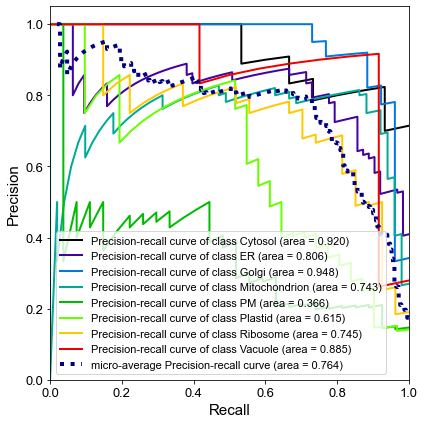

In [12]:
skplt.metrics.plot_precision_recall(df_att.markers, df_att.iloc[:, :8],
                      figsize=(6, 6))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Recall',fontsize=15)
plt.ylabel('Precision',fontsize=15)
plt.legend(fontsize=11)
plt.title(None)
plt.tight_layout()
# plt.savefig('../figure/nikolovski2014_DeepSPatt_PRC.pdf')

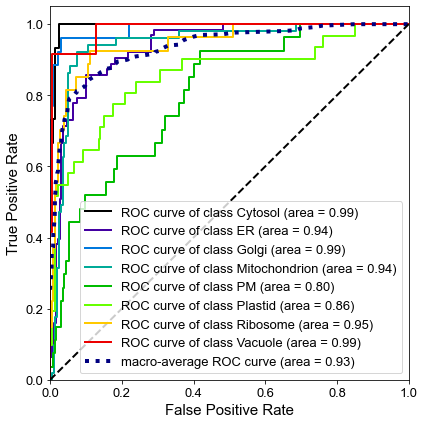

In [25]:
skplt.metrics.plot_roc(df_att.markers, df_att.iloc[:, :8],plot_micro=False,
                      figsize=(6, 6))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.legend(fontsize=13)
plt.title(None)
plt.tight_layout()
plt.savefig('../figure/nikolovski2014_DeepSPatt_ROC.pdf')

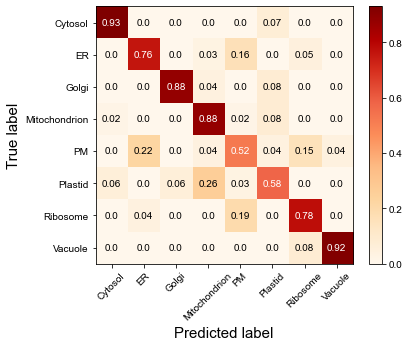

In [14]:
skplt.metrics.plot_confusion_matrix(df_att.markers,
                                    df_att.pred,
                                    normalize=True,
                                   figsize=(6, 5),
                                   cmap='OrRd')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel('True label',fontsize=15)
plt.xlabel('Predicted label',fontsize=15)
plt.title(None)
plt.savefig('../figure/nikolovski2014_DeepSPatt_CF.pdf')

In [34]:
print(classification_report(df_att.markers, df_att.pred, digits=3))

               precision    recall  f1-score   support

      Cytosol      0.824     0.933     0.875        15
           ER      0.873     0.762     0.814        63
        Golgi      0.920     0.885     0.902        26
Mitochondrion      0.789     0.882     0.833        51
           PM      0.452     0.519     0.483        27
      Plastid      0.692     0.581     0.632        31
     Ribosome      0.724     0.778     0.750        27
      Vacuole      0.917     0.917     0.917        12

     accuracy                          0.770       252
    macro avg      0.774     0.782     0.776       252
 weighted avg      0.777     0.770     0.771       252



# DeepSP without attention

In [15]:
df_no = pd.read_csv('./DeepSP_noatt/trainresult.csv', index_col=0)
df_no.head()

,Cytosol,ER,Golgi,Mitochondrion,PM,Plastid,Ribosome,Vacuole,markers,score,pred,FDR,qvalue
Protein_ID,,,,,,,,,,,,,
AT5G25100,5.554468e-12,2.110489e-07,0.999996,4.230217e-10,4.849813e-09,0.000004,7.869570e-11,3.750404e-10,Golgi,0.999996,Golgi,0.0,0.0
AT4G11220,7.601836e-07,9.999815e-01,0.000010,5.730636e-09,1.745175e-06,0.000005,1.065593e-06,1.471837e-08,ER,0.999982,ER,0.0,0.0
AT2G35610,1.054535e-10,1.406036e-06,0.999928,7.582459e-08,6.507170e-08,0.000070,6.952848e-10,7.749517e-09,Golgi,0.999928,Golgi,0.0,0.0
AT3G21190,4.564937e-09,2.536302e-05,0.999775,7.141755e-07,3.674322e-07,0.000199,2.722348e-08,5.905646e-08,Golgi,0.999775,Golgi,0.0,0.0
AT5G20350,8.158403e-08,4.046369e-05,0.999283,5.231802e-07,1.557476e-06,0.000674,3.041684e-08,4.303026e-07,Golgi,0.999283,Golgi,0.0,0.0


In [22]:
print(classification_report(df_no.markers, df_no.pred, digits=3))

               precision    recall  f1-score   support

      Cytosol      0.765     0.867     0.812        15
           ER      0.789     0.714     0.750        63
        Golgi      0.917     0.846     0.880        26
Mitochondrion      0.808     0.824     0.816        51
           PM      0.444     0.444     0.444        27
      Plastid      0.607     0.548     0.576        31
     Ribosome      0.657     0.852     0.742        27
      Vacuole      0.917     0.917     0.917        12

     accuracy                          0.734       252
    macro avg      0.738     0.751     0.742       252
 weighted avg      0.737     0.734     0.733       252



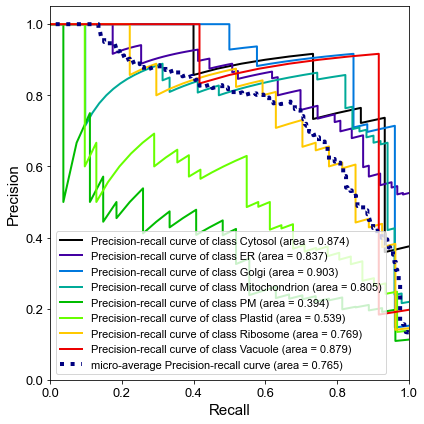

In [16]:
skplt.metrics.plot_precision_recall(df_no.markers, df_no.iloc[:, :8],
                      figsize=(6, 6))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Recall',fontsize=15)
plt.ylabel('Precision',fontsize=15)
plt.legend(fontsize=11)
plt.title(None)
plt.tight_layout()
# plt.savefig('../figure/nikolovski2014_DeepSPnoatt_PRC.pdf')

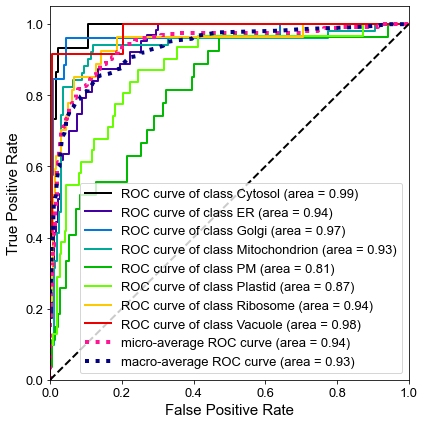

In [29]:
skplt.metrics.plot_roc(df_no.markers, df_no.iloc[:, :8],
                      figsize=(6, 6))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.legend(fontsize=13)
plt.title(None)
plt.tight_layout()
plt.savefig('../figure/nikolovski2014_DeepSPnoatt_ROC.pdf')

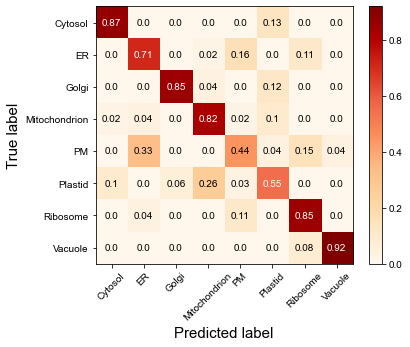

In [18]:
skplt.metrics.plot_confusion_matrix(df_no.markers,
                                    df_no.pred,
                                    normalize=True,
                                   figsize=(6, 5),
                                   cmap='OrRd')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel('True label',fontsize=15)
plt.xlabel('Predicted label',fontsize=15)
plt.title(None)
plt.savefig('../figure/nikolovski2014_DeepSPnoatt_CF.pdf')

# Comapre

In [108]:
def metrics_cmp(y_true, y_pred):
    cm = confusion_matrix(df_att.markers, df_att.pred)
    markers = sorted(y_true.unique())
    result = pd.DataFrame({'Precision': precision_score(y_true, y_pred, average=None),
                 'Recall': recall_score(y_true, y_pred, average=None),
                 'F1-score': f1_score(y_true, y_pred, average=None),
                 'Accuracy': np.diagonal(cm / cm.sum(1))})
    result.index = sorted(y_true.unique())
    result.index.name = 'markers'
    result.loc['avg'] = [precision_score(y_true, y_pred, average='macro'),
                        recall_score(y_true, y_pred, average='macro'),
                        f1_score(y_true, y_pred, average='macro'),
                        accuracy_score(y_true, y_pred)]
    return result.round(3)

In [114]:
no_result = metrics_cmp(df_no.markers, df_no.pred)
no_result

,Precision,Recall,F1-score,Accuracy
markers,,,,
Cytosol,0.765,0.867,0.812,0.933
ER,0.789,0.714,0.750,0.762
Golgi,0.917,0.846,0.880,0.885
Mitochondrion,0.808,0.824,0.816,0.882
PM,0.444,0.444,0.444,0.519
Plastid,0.607,0.548,0.576,0.581
Ribosome,0.657,0.852,0.742,0.778
Vacuole,0.917,0.917,0.917,0.917
avg,0.738,0.751,0.742,0.734


In [130]:
att_result = metrics_cmp(df_att.markers, df_att.pred)
att_result

,Precision,Recall,F1-score,Accuracy
markers,,,,
Cytosol,0.824,0.933,0.875,0.933
ER,0.873,0.762,0.814,0.762
Golgi,0.920,0.885,0.902,0.885
Mitochondrion,0.789,0.882,0.833,0.882
PM,0.452,0.519,0.483,0.519
Plastid,0.692,0.581,0.632,0.581
Ribosome,0.724,0.778,0.750,0.778
Vacuole,0.917,0.917,0.917,0.917
avg,0.774,0.782,0.776,0.770


In [215]:
def markerselect(marker):
    a = pd.DataFrame(no_result.loc[marker])
    a['Method'] = 'Without Attention'
    b = pd.DataFrame(att_result.loc[marker])
    b['Method'] = 'With Attention'
    return  a

In [221]:
no_result

,Precision,Recall,F1-score,Accuracy
markers,,,,
Cytosol,0.765,0.867,0.812,0.933
ER,0.789,0.714,0.750,0.762
Golgi,0.917,0.846,0.880,0.885
Mitochondrion,0.808,0.824,0.816,0.882
PM,0.444,0.444,0.444,0.519
Plastid,0.607,0.548,0.576,0.581
Ribosome,0.657,0.852,0.742,0.778
Vacuole,0.917,0.917,0.917,0.917
avg,0.738,0.751,0.742,0.734


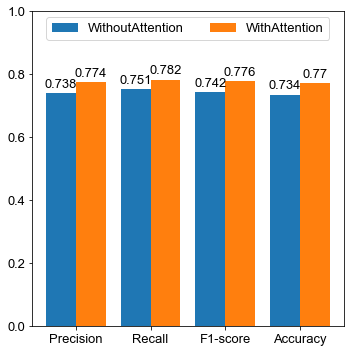

In [327]:
plt.rcParams['font.sans-serif']=['ARIAL']
marker='avg'
Metrics = no_result.columns
x = np.arange(len(Metrics))
width = 0.4
fig, ax = plt.subplots(figsize=(5, 5))
rects1 = ax.bar(x - width/2, no_result.loc[marker], width, label='WithoutAttention')
rects2 = ax.bar(x + width/2, att_result.loc[marker], width, label='WithAttention')
ax.set_ylabel(None)
ax.set_title(None)
plt.xticks(x, Metrics, fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0,1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5,1),
           ncol=2,fancybox=True,shadow=False,fontsize=13)

plt.bar_label(rects1, padding=3, fontsize=13)
plt.bar_label(rects2, padding=3,fontsize=13)
fig.tight_layout()

plt.savefig('../figure/nikolovski2014_avg_compare.pdf')

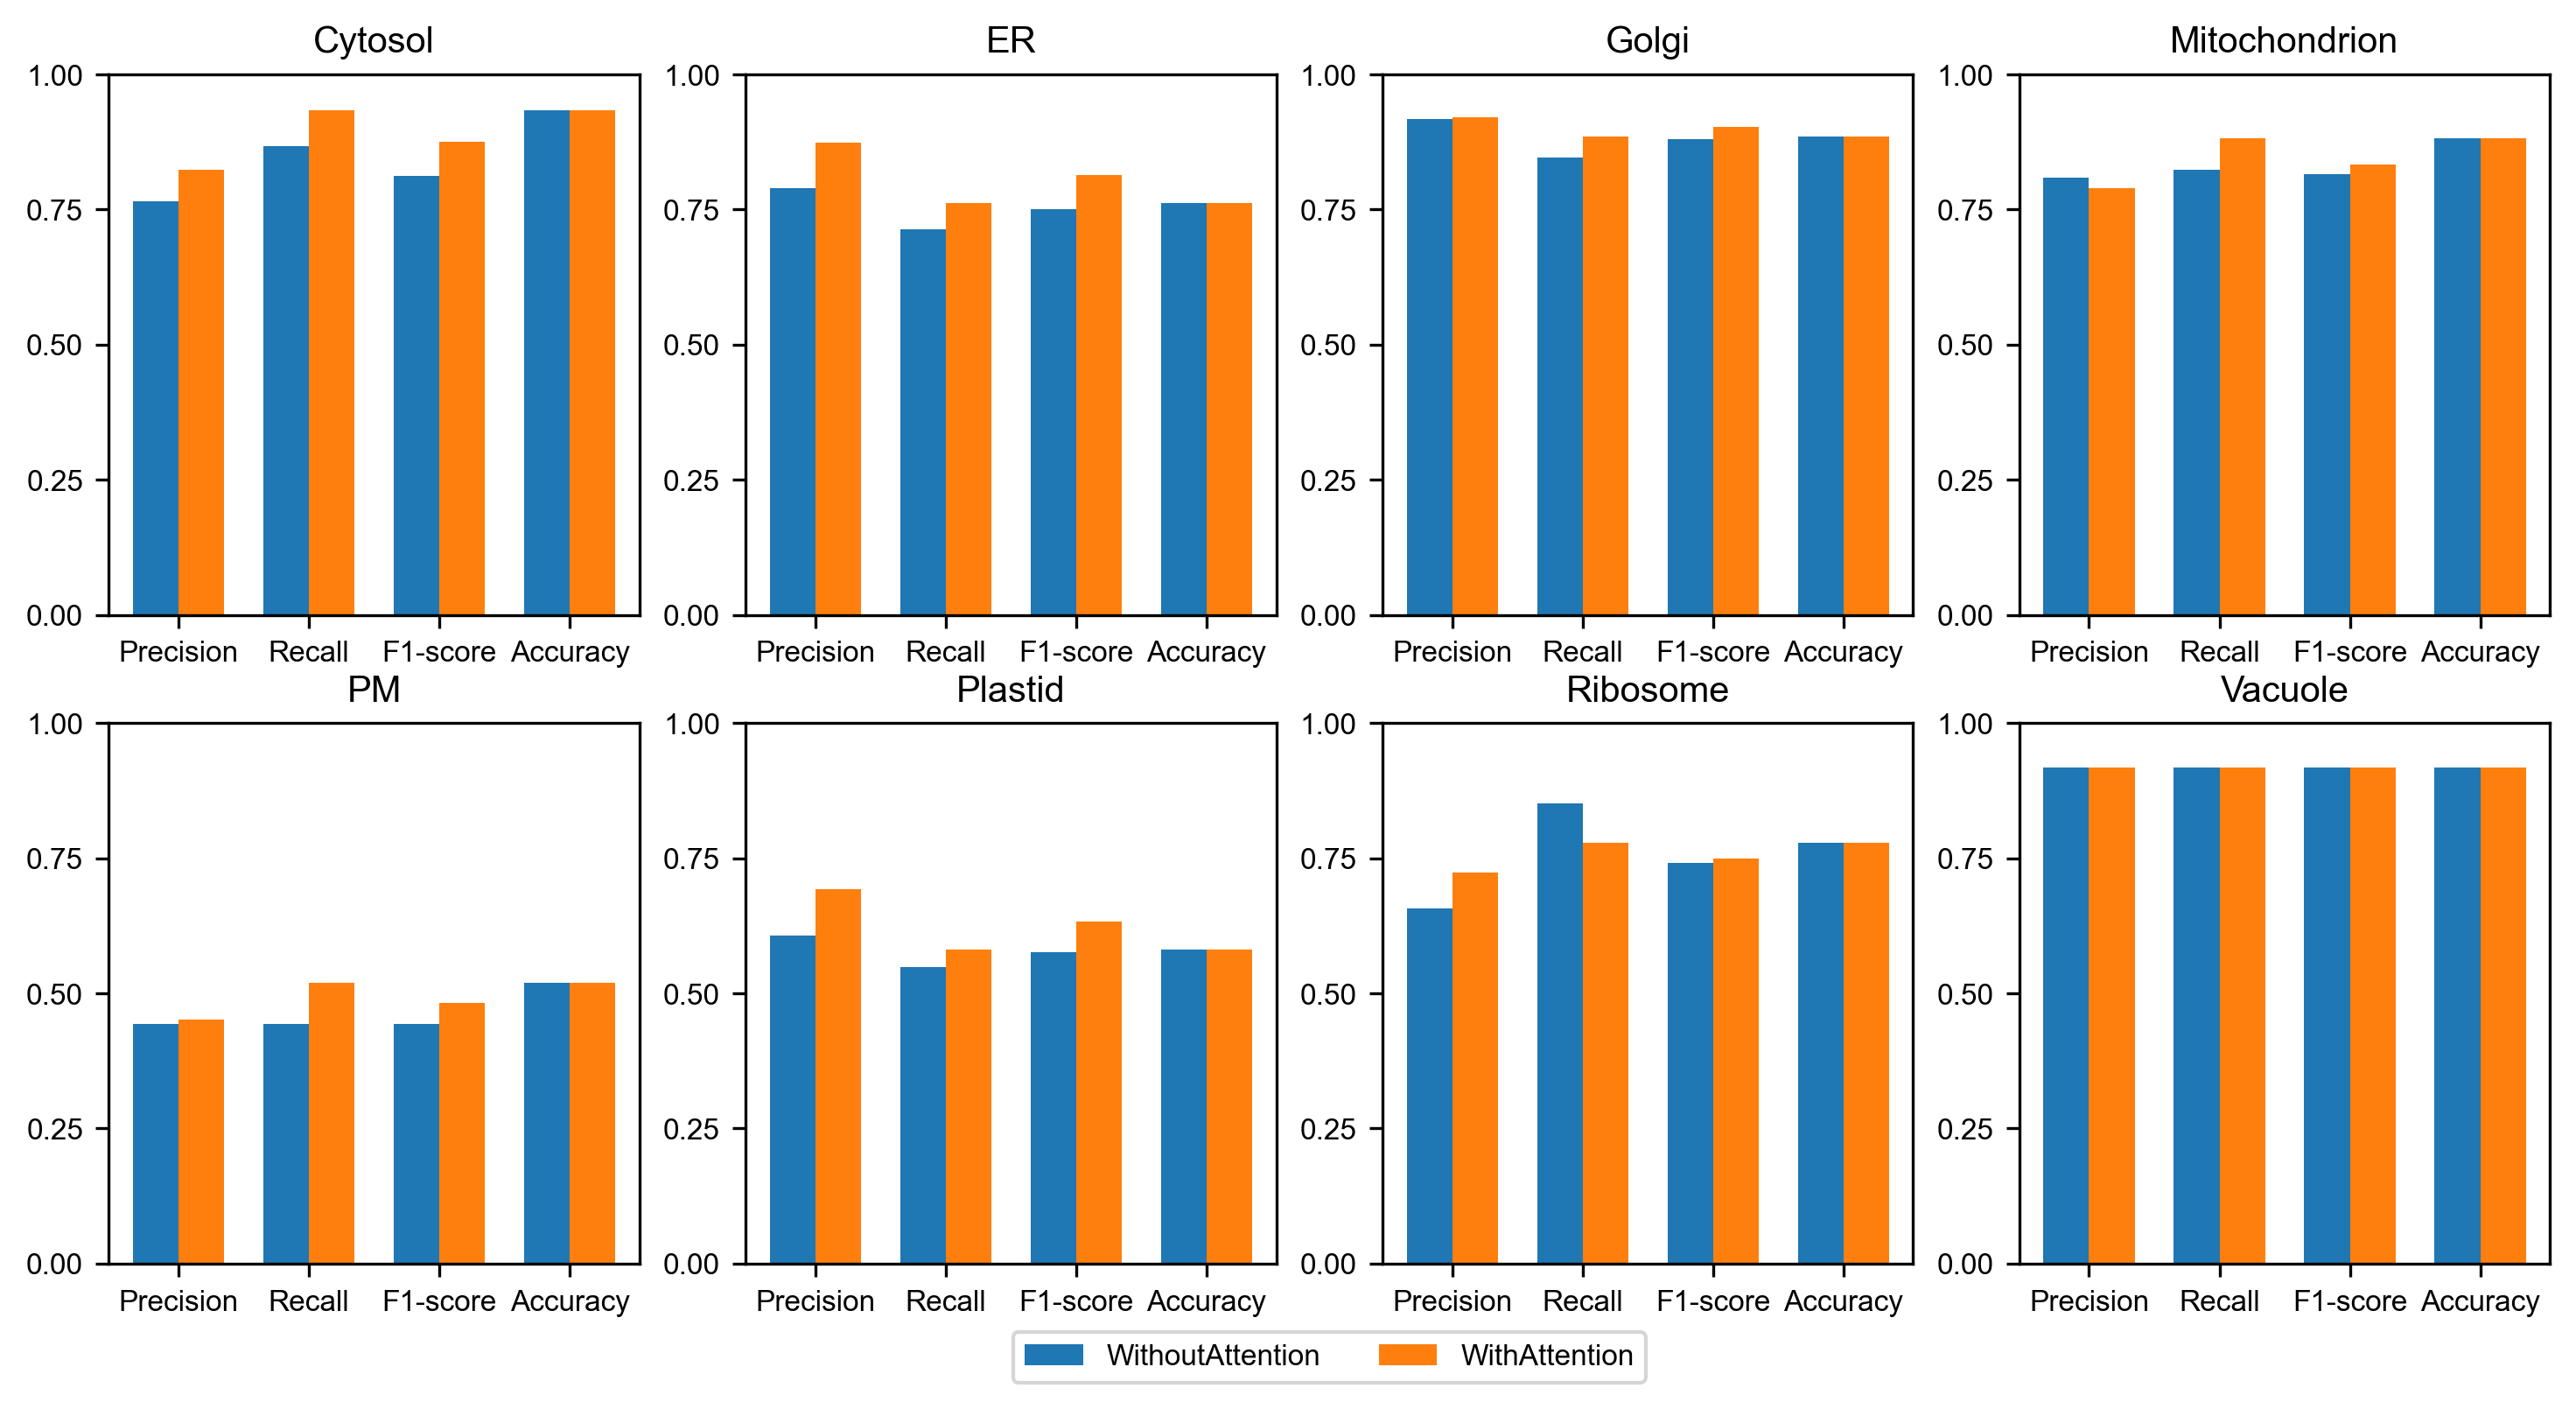

In [322]:
plt.figure(figsize=(12, 6), dpi=300)
for i, marker in enumerate(sorted(df_att.markers.unique())):
    width=0.35
    ax = plt.subplot(2,4, i + 1)
    rects1 = ax.bar(x - width/2, no_result.loc[marker], width, label='WithoutAttention')
    rects2 = ax.bar(x + width/2, att_result.loc[marker], width, label='WithAttention')
    plt.xticks(x, Metrics, fontsize=8)
    plt.yticks(fontsize=8)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_title(marker,fontsize=10)
    plt.ylim(0,1)
#     plt.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(-1.3,-0.1),
               ncol=2,fancybox=True,shadow=False,fontsize=8)
fig.tight_layout()
plt.savefig('../figure/nikolovski2014_marker_compare.pdf')

In [342]:
data = pd.read_csv('./DeepSP_att/nikolovski2014.csv')
DeepSPtest = pd.read_csv('./DeepSP_att/testresult.csv')[['Protein_ID', 'pred', 
                                                    'score', 'toppred']]
DeepSPtest.columns = ['Protein_ID', 'DeepSP classification',
                      'DeepSP score', 'Curated DeepSP predictions']
DeepSPtest.shape

(1133, 4)

In [343]:
result = pd.merge(data, DeepSPtest, on='Protein_ID', how='left')
result.loc[result['DeepSP classification'].isna(),
           'DeepSP classification'] = result.loc[
               result['DeepSP classification'].isna(), 'markers']
result.loc[result['DeepSP score'].isna(),'DeepSP score'] = 1.0
result.loc[result['Curated DeepSP predictions'].isna(),
           'Curated DeepSP predictions'] = result.loc[
               result['Curated DeepSP predictions'].isna(), 'markers']
result.shape

(1385, 25)

In [346]:
result.to_csv('./DeepSP_att/nikolovski2014_DeepSCP_result.csv', index=None)